# LeetCode #10: Regular Expression Matching



https://leetcode.com/problems/regular-expression-matching/



## Comparison of Approaches



| Approach | Time Complexity | Space Complexity |

| :--- | :--- | :--- |

| **Brute Force Recursion** | $O(2^{m+n})$ | $O(m+n)$ |

| **Memoization (Top-Down DP)** | $O(m \cdot n)$ | $O(m \cdot n)$ |

| **Optimal: Bottom-Up DP** ★ | $O(m \cdot n)$ | $O(m \cdot n)$ |



---



## Understanding the Methods



### Brute Force Recursion

Try every possible match recursively: at each position, branch on whether `*` consumes zero or one more character. No caching means exponential time on overlapping subproblems.



### Memoization (Top-Down DP)

Same recursion but cache each (i, j) result so each subproblem is solved only once. Reduces to $O(m \cdot n)$ time and space, but builds the call stack downward.



### Optimal: Bottom-Up DP ★

Build a 2D table `dp[i][j]` = true if `s[0..i-1]` matches `p[0..j-1]`. Fill row by row: no recursion, no stack frames, cache-friendly memory access.



**Why this is better than Memoization:** Same Big-O, but eliminates recursion overhead and call-stack allocation. Avoids stack-overflow risk on long inputs.



**Constraints:**

* `1 <= s.length <= 20`

* `1 <= p.length <= 20`

* `s` contains only lowercase English letters

* `p` contains only lowercase English letters, `.`, and `*`

* Every `*` is guaranteed to have a previous valid character to match

## Solutions



### C#

In [ ]:
public class Solution {

    public bool IsMatch(string s, string p) {

        int m = s.Length, n = p.Length;

        bool[,] dp = new bool[m + 1, n + 1];

        // Empty string vs empty pattern always matches

        dp[0, 0] = true;

        // Empty string can match patterns like a*, a*b* (zero occurrences)

        for (int j = 2; j <= n; j++)

            if (p[j - 1] == '*') dp[0, j] = dp[0, j - 2];

        for (int i = 1; i <= m; i++) {

            for (int j = 1; j <= n; j++) {

                if (p[j - 1] == '*') {

                    // Zero occurrences: skip the x* pair entirely

                    dp[i, j] = dp[i, j - 2];

                    // One or more: preceding char must match current s char

                    if (p[j - 2] == s[i - 1] || p[j - 2] == '.')

                        dp[i, j] |= dp[i - 1, j];

                } else if (p[j - 1] == s[i - 1] || p[j - 1] == '.') {

                    // Direct match or wildcard dot

                    dp[i, j] = dp[i - 1, j - 1];

                }

            }

        }

        return dp[m, n];

    }

}

### Python

In [ ]:
class Solution:

    def isMatch(self, s: str, p: str) -> bool:

        m, n = len(s), len(p)

        dp = [[False] * (n + 1) for _ in range(m + 1)]

        # Empty string vs empty pattern always matches

        dp[0][0] = True

        # Empty string can match patterns like a*, a*b* (zero occurrences)

        for j in range(2, n + 1):

            if p[j - 1] == '*':

                dp[0][j] = dp[0][j - 2]

        for i in range(1, m + 1):

            for j in range(1, n + 1):

                if p[j - 1] == '*':

                    # Zero occurrences: skip the x* pair entirely

                    dp[i][j] = dp[i][j - 2]

                    if p[j - 2] == s[i - 1] or p[j - 2] == '.':

                        dp[i][j] = dp[i][j] or dp[i - 1][j]

                elif p[j - 1] == s[i - 1] or p[j - 1] == '.':

                    # Direct match or wildcard dot

                    dp[i][j] = dp[i - 1][j - 1]

        return dp[m][n]

### Go

In [ ]:
func isMatch(s string, p string) bool {

    m, n := len(s), len(p)

    dp := make([][]bool, m+1)

    for i := range dp {

        dp[i] = make([]bool, n+1)

    }

    // Empty string vs empty pattern always matches

    dp[0][0] = true

    // Empty string can match patterns like a*, a*b* (zero occurrences)

    for j := 2; j <= n; j++ {

        if p[j-1] == '*' {

            dp[0][j] = dp[0][j-2]

        }

    }

    for i := 1; i <= m; i++ {

        for j := 1; j <= n; j++ {

            if p[j-1] == '*' {

                // Zero occurrences: skip the x* pair entirely

                dp[i][j] = dp[i][j-2]

                // One or more: preceding char must match current s char

                if p[j-2] == s[i-1] || p[j-2] == '.' {

                    dp[i][j] = dp[i][j] || dp[i-1][j]

                }

            } else if p[j-1] == s[i-1] || p[j-1] == '.' {

                // Direct match or wildcard dot

                dp[i][j] = dp[i-1][j-1]

            }

        }

    }

    return dp[m][n]

}

### Rust

In [ ]:
impl Solution {

    pub fn is_match(s: String, p: String) -> bool {

        let s: Vec<char> = s.chars().collect();

        let p: Vec<char> = p.chars().collect();

        let m = s.len();

        let n = p.len();

        let mut dp = vec![vec![false; n + 1]; m + 1];

        // Empty string vs empty pattern always matches

        dp[0][0] = true;

        // Empty string can match patterns like a*, a*b* (zero occurrences)

        for j in 2..=n {

            if p[j - 1] == '*' {

                dp[0][j] = dp[0][j - 2];

            }

        }

        for i in 1..=m {

            for j in 1..=n {

                if p[j - 1] == '*' {

                    // Zero occurrences: skip the x* pair entirely

                    dp[i][j] = dp[i][j - 2];

                    // One or more: preceding char must match current s char

                    if p[j - 2] == s[i - 1] || p[j - 2] == '.' {

                        dp[i][j] = dp[i][j] || dp[i - 1][j];

                    }

                } else if p[j - 1] == s[i - 1] || p[j - 1] == '.' {

                    // Direct match or wildcard dot

                    dp[i][j] = dp[i - 1][j - 1];

                }

            }

        }

        dp[m][n]

    }

}

## Example Scenarios



**Example 1 — Common Case**\n
**Input:** `s = "aa"`, `p = "a*"`\n
Pattern `a*` means zero-or-more `a`. The `*` triggers the "one or more" branch: `dp[1][2]` inherits from `dp[0][2]` (zero) and `dp[i-1][j]` = `dp[0][2]` (one); `dp[2][2]` similarly inherits `dp[1][2]` → **true**.



**Example 2 — Slightly Complex**\n
**Input:** `s = "aab"`, `p = "c*a*b"`\n
`c*` consumes zero c's (zero-occurrence branch sets `dp[0][2] = dp[0][0] = true`); `a*` then consumes both `a`'s; literal `b` matches the final `b` → **true**.



**Example 3 — Edge Case: Time Factor**\n
**Input:** `s = "aaaaaab"`, `p = "a*a*a*b"`\n
Three overlapping `a*` groups against a 6-character run of `a`s forces the DP to evaluate every cell in a $7 \times 8 = 56$ table; each `*` cell checks two sub-results. This is the worst-case structure that makes brute-force exponential → **true**.



**Example 4 — Edge Case: Space Factor**\n
**Input:** `s = "mississippi"`, `p = "mis*is*p*."`\n
A full $12 \times 11 = 132$-cell table is allocated and traversed — maximum space usage relative to these constraint limits. The pattern almost matches but `p*.` cannot cover the double `p` in "mississippi" → **false**.



**Example 5 — Almost-Impossible but Plausible**\n
**Input:** `s = ""`, `p = "a*b*c*"`\n
The inner loop never executes ($m = 0$). The answer comes entirely from the initialization row: `dp[0][2] = dp[0][0]` (true), `dp[0][4] = dp[0][2]` (true), `dp[0][6] = dp[0][4]` (true) — each `x*` pair can match zero occurrences → **true**.

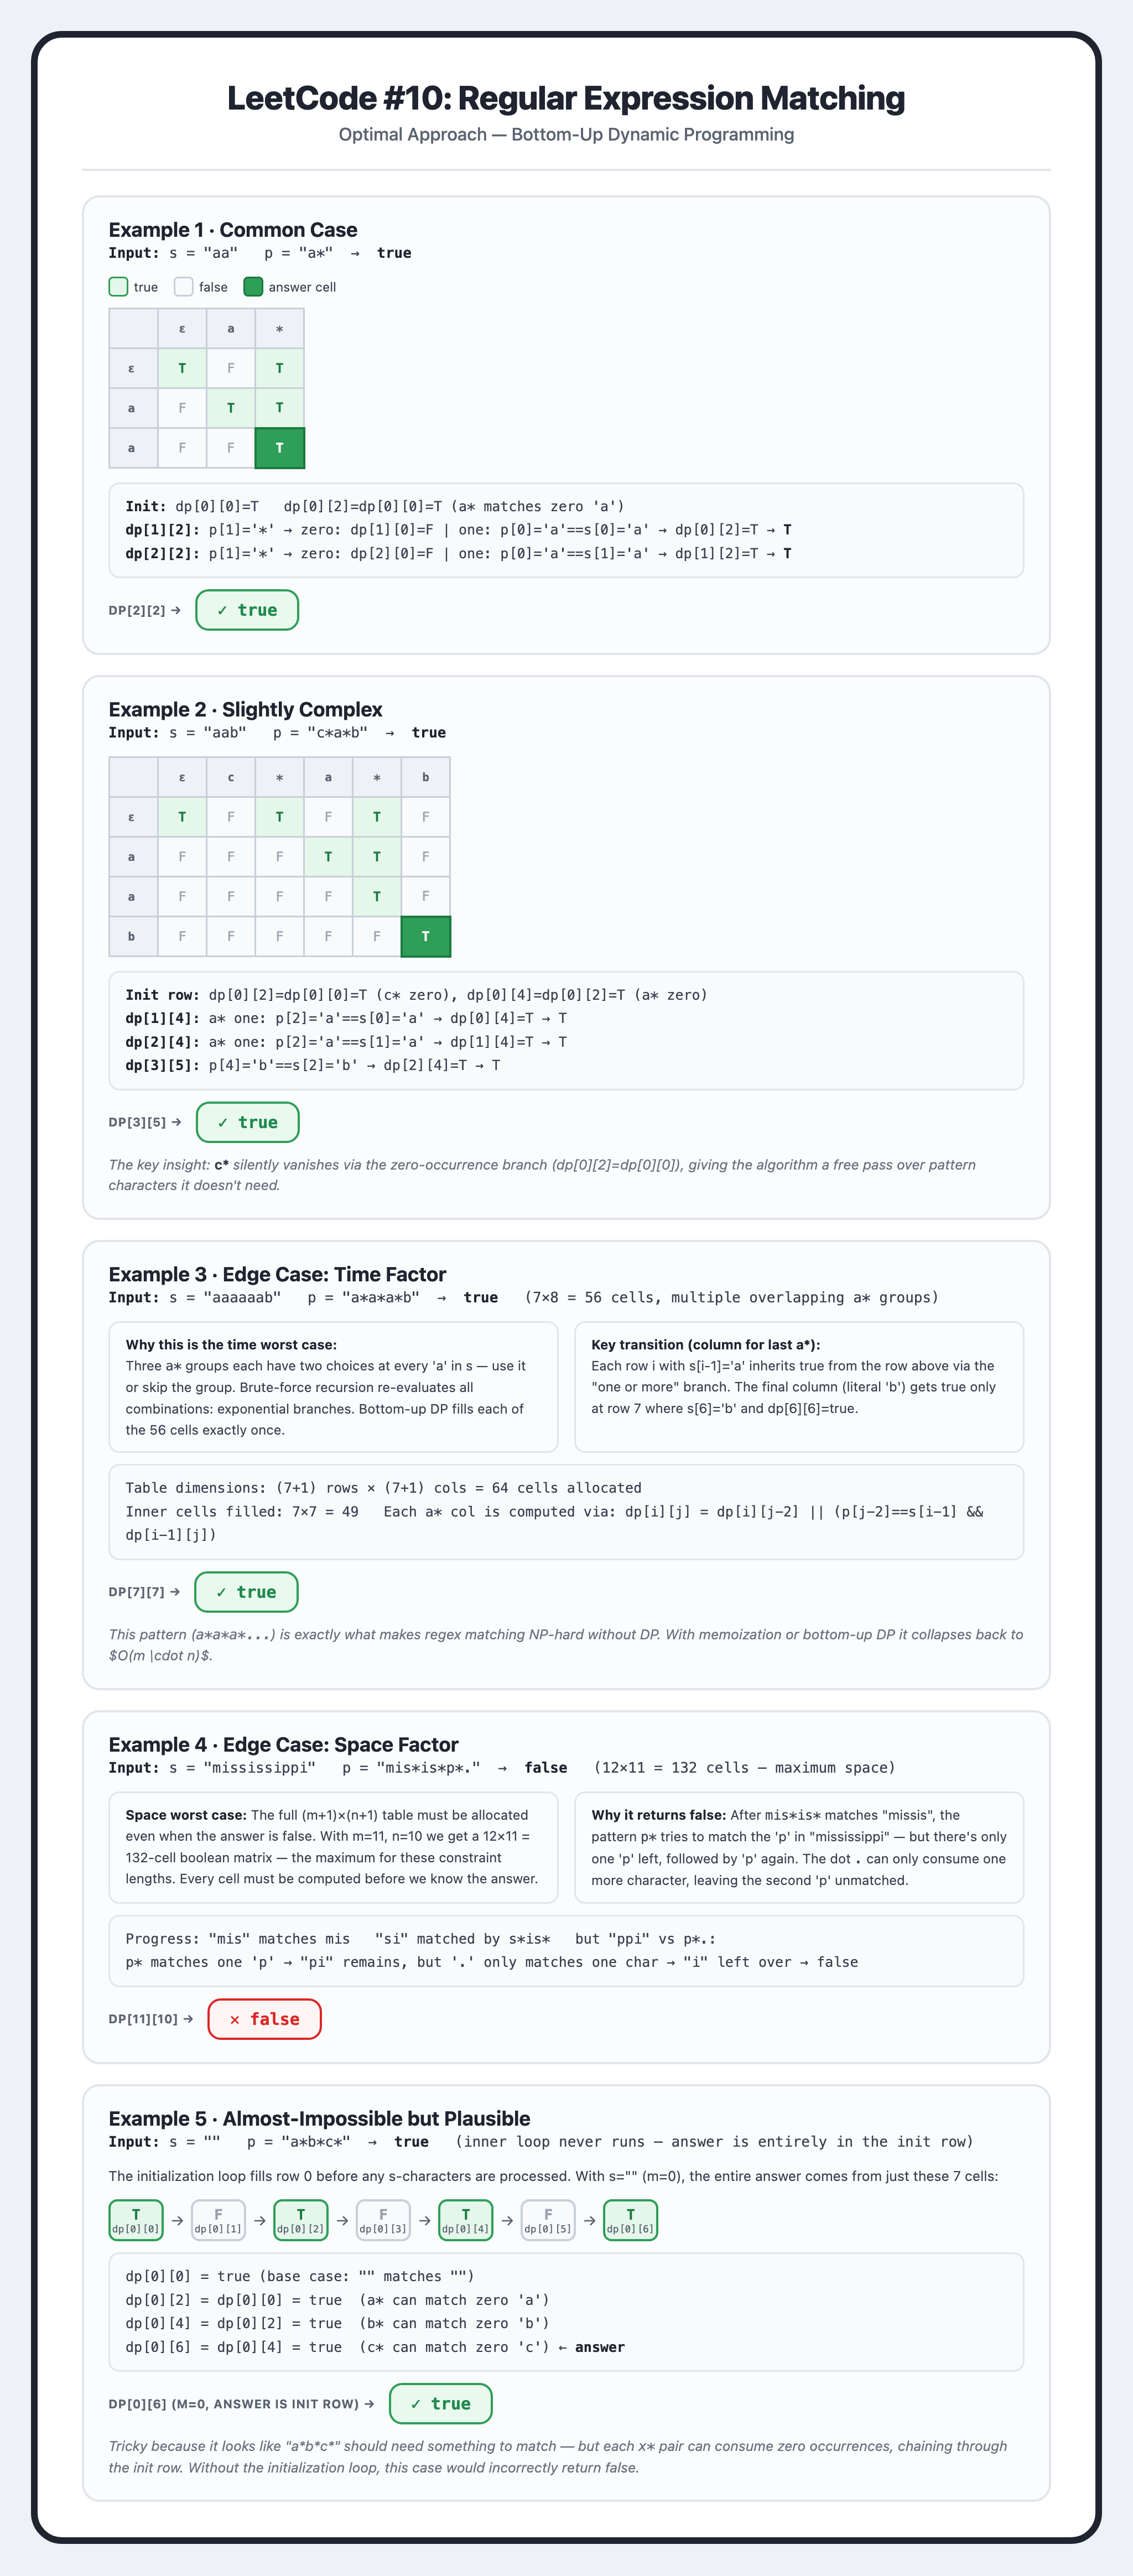